In [5]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_monthly_summary.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_yearly_performance.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [7]:
file_path = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (33364, 15)


,coin_id,coin_name,symbol,market_cap_rank,timestamp,date,price,market_cap,volume,daily_return,price_ma7,price_ma30,volatility_7d,cumulative_return,month
0,aave,Aave,AAVE,46,2024-12-04 00:00:00,2024-12-04,241.886714,3.633154e+09,1.181708e+09,NaN,241.886714,241.886714,NaN,NaN,2024-12
1,aave,Aave,AAVE,46,2024-12-05 00:00:00,2024-12-05,255.966610,3.841768e+09,1.191179e+09,5.820864,248.926662,248.926662,NaN,5.820864,2024-12
2,aave,Aave,AAVE,46,2024-12-06 00:00:00,2024-12-06,248.589404,3.725870e+09,8.706666e+08,-2.882097,248.814243,248.814243,6.153922,2.771004,2024-12
3,aave,Aave,AAVE,46,2024-12-07 00:00:00,2024-12-07,281.755167,4.226339e+09,1.120551e+09,13.341583,257.049474,257.049474,8.119016,16.482283,2024-12
4,aave,Aave,AAVE,46,2024-12-08 00:00:00,2024-12-08,282.398618,4.241226e+09,6.553344e+08,0.228372,262.119303,262.119303,7.120498,16.748297,2024-12


Anomaly Summary:


,Anomaly_Type,Count
0,Spike,857
1,Drop,743


Sample Anomalies:


,coin_id,coin_name,date,price,return_pct,return_zscore,anomaly_type
4583,bitget-token,Bitget Token,2024-12-05,1.793306,11.770052,2.542988,Spike
12761,htx-dao,HTX DAO,2024-12-05,0.000003,-13.711545,-4.558750,Drop
15689,kucoin-shares,KuCoin,2024-12-05,13.450321,6.374570,2.418077,Spike
16055,leo-token,LEO Token,2024-12-05,9.528163,6.669293,4.125306,Spike
16787,mantle,Mantle,2024-12-05,1.052280,15.795525,2.807374,Spike
22891,shiba-inu,Shiba Inu,2024-12-05,0.000033,14.473475,3.510533,Spike
26887,tron,TRON,2024-12-05,0.328735,-20.899137,-7.980187,Drop
29257,vechain,VeChain,2024-12-05,0.068096,-12.431181,-2.510734,Drop
2388,binance-bridged-usdt-bnb-smart-chain,Binance Bridged USDT (BNB Smart Chain),2024-12-06,1.001739,0.437043,2.816093,Spike
7467,dai,Dai,2024-12-06,1.001296,0.213175,3.016072,Spike


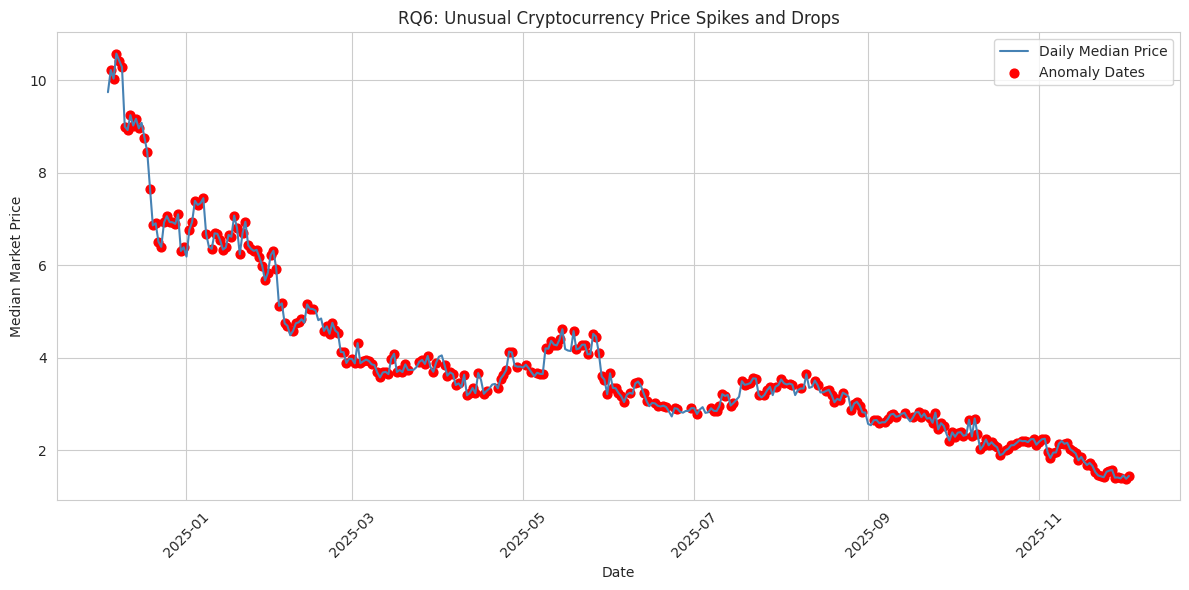

In [12]:
# RQ6: Anomaly Detection
# Objective: Detect unusual price spikes and drops

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower().str.strip()
df["date"] = pd.to_datetime(df["date"])

# Sort data by coin and date
df = df.sort_values(["coin_id", "date"]).reset_index(drop=True)

# Calculate daily percentage return within each cryptocurrency
df["return_pct"] = df.groupby("coin_id")["price"].pct_change() * 100

# Calculate z-score of returns within each cryptocurrency
coin_mean = df.groupby("coin_id")["return_pct"].transform("mean")
coin_std = df.groupby("coin_id")["return_pct"].transform("std")

df["return_zscore"] = (df["return_pct"] - coin_mean) / coin_std

# Flag anomalies
df["anomaly"] = df["return_zscore"].abs() > 2

# Create anomaly type label
df["anomaly_type"] = "Normal"
df.loc[(df["anomaly"]) & (df["return_pct"] > 0), "anomaly_type"] = "Spike"
df.loc[(df["anomaly"]) & (df["return_pct"] < 0), "anomaly_type"] = "Drop"

# Save anomaly table
anomalies_df = df[df["anomaly"]].copy()
anomalies_df = anomalies_df[[
    "coin_id", "coin_name", "date", "price", "return_pct", "return_zscore", "anomaly_type"
]].sort_values(["date", "coin_id"])

anomalies_df.to_csv("/kaggle/working/RQ6_anomalies.csv", index=False)

# Save summary table
summary_df = anomalies_df["anomaly_type"].value_counts().reset_index()
summary_df.columns = ["Anomaly_Type", "Count"]
summary_df.to_csv("/kaggle/working/RQ6_anomaly_summary.csv", index=False)

print("Anomaly Summary:")
display(summary_df)

print("Sample Anomalies:")
display(anomalies_df.head(10))

# Figure: market-level median price with anomaly dates highlighted
daily_market = (
    df.groupby("date")
      .agg(median_price=("price", "median"))
      .reset_index()
      .sort_values("date")
)

anomaly_dates = anomalies_df["date"].drop_duplicates()

highlight_df = daily_market[daily_market["date"].isin(anomaly_dates)].copy()

plt.figure(figsize=(12, 6))
plt.plot(daily_market["date"], daily_market["median_price"], color="steelblue", label="Daily Median Price")
plt.scatter(highlight_df["date"], highlight_df["median_price"], color="red", label="Anomaly Dates", s=40)

plt.title("RQ6: Unusual Cryptocurrency Price Spikes and Drops")
plt.xlabel("Date")
plt.ylabel("Median Market Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/RQ6_anomalies.pdf")
plt.show()
